# **Tweet Sentiment Analysis with MLPs**

### **Assignment 3a - Natural Language Processing - MSc. Computer Science, AUEB [2025-2026]**

> Maria Schoinaki, MSc Student
>
> Department of Informatics, Athens University of Economics and Business
>
> mar.schoinaki@aueb.gr

> Electra Papadopoulou, MSc Student
>
> Department of Informatics, Athens University of Economics and Business
>
> elec.papadopoulou@aueb.gr

> Leonidas Kontogiannis, MSc Student
>
> Department of Informatics, Athens University of Economics and Business
>
> leo.kontogiannis@aueb.gr

## **Text Classification with MLPs**

In [1]:
%pip install matplotlib seaborn nltk scikit-learn gensim numpy torch --quiet

## **Imports**

In [2]:
from sklearn.model_selection import train_test_split
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

In [3]:
os.environ["KAGGLE_USERNAME"] = "mariaschoinaki" #add your own username
os.environ["KAGGLE_KEY"] = "598a2d8ab8b0a2b884936c4777ad9509" # add your own key

In [4]:
!pip install -q kaggle
DATA_DIR = "/content/data"
!mkdir -p $DATA_DIR

!kaggle competitions download -c twitter-sentiment-analysis2 -p $DATA_DIR --force
!unzip -qo "$DATA_DIR/twitter-sentiment-analysis2.zip" -d $DATA_DIR

!ls -lh $DATA_DIR


  0% 0.00/14.6M [00:00<?, ?B/s]
100% 14.6M/14.6M [00:00<00:00, 160MB/s]
total 48M
-rw-r--r-- 1 root root  25M Nov 28  2019 test.csv
-rw-r--r-- 1 root root 8.3M Nov 28  2019 train.csv
-rw-r--r-- 1 root root  15M Nov 28  2019 twitter-sentiment-analysis2.zip


In [5]:
try:
    df = pd.read_csv("/content/data/train.csv")
except UnicodeDecodeError:
    df = pd.read_csv("/content/data/train.csv", encoding="ISO-8859-1")

print("Loaded CSV successfully.")
print(df.shape)
df.head()

Loaded CSV successfully.
(99989, 3)


,ItemID,Sentiment,SentimentText
0,1,0,is so sad for my APL frie...
1,2,0,I missed the New Moon trail...
2,3,1,omg its already 7:30 :O
3,4,0,.. Omgaga. Im sooo im gunna CRy. I'...
4,5,0,i think mi bf is cheating on me!!! ...


In [6]:
# Display basic info
print("Full dataset shape:", df.shape)
print(df['Sentiment'].value_counts())

Full dataset shape: (99989, 3)
Sentiment
1    56457
0    43532
Name: count, dtype: int64


### **Exploring the Dataset**

In [7]:
x, y = df['SentimentText'], df['Sentiment']
print(len(x))
print(len(y))

99989
99989


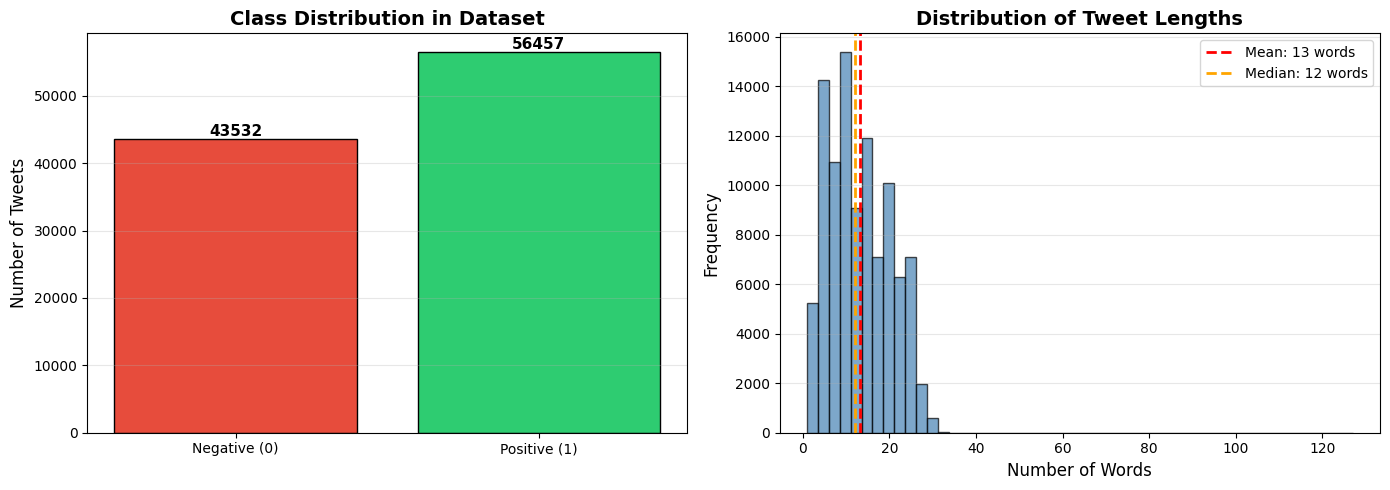

DATASET SUMMARY
Total tweets: 99989
Negative tweets: 43532 (43.5%)
Positive tweets: 56457 (56.5%)

Review Length Statistics:
  Min length: 1 words
  Max length: 127 words
  Mean length: 13.3 words
  Median length: 12.0 words
  Std deviation: 7.0 words


In [8]:
import matplotlib.pyplot as plt

# Plot 1: Class Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class distribution
class_counts = np.bincount(y)
axes[0].bar(['Negative (0)', 'Positive (1)'], class_counts, color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_ylabel('Number of Tweets', fontsize=12)
axes[0].set_title('Class Distribution in Dataset', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
# Add count labels on bars
for i, count in enumerate(class_counts):
    axes[0].text(i, count + 20, str(count), ha='center', va='bottom', fontsize=11, fontweight='bold')

# Plot 2: Tweet Length Distribution
tweet_lengths = [len(str(tweet).split()) for tweet in x]
axes[1].hist(tweet_lengths, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].axvline(np.mean(tweet_lengths), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(tweet_lengths):.0f} words')
axes[1].axvline(np.median(tweet_lengths), color='orange', linestyle='--', linewidth=2, label=f'Median: {np.median(tweet_lengths):.0f} words')
axes[1].set_xlabel('Number of Words', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Distribution of Tweet Lengths', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("="*60)
print("DATASET SUMMARY")
print("="*60)
print(f"Total tweets: {len(x)}")
print(f"Negative tweets: {class_counts[0]} ({class_counts[0]/len(x)*100:.1f}%)")
print(f"Positive tweets: {class_counts[1]} ({class_counts[1]/len(x)*100:.1f}%)")
print(f"\nReview Length Statistics:")
print(f"  Min length: {min(tweet_lengths)} words")
print(f"  Max length: {max(tweet_lengths)} words")
print(f"  Mean length: {np.mean(tweet_lengths):.1f} words")
print(f"  Median length: {np.median(tweet_lengths):.1f} words")
print(f"  Std deviation: {np.std(tweet_lengths):.1f} words")
print("="*60)

###  **Preprocess dataset**

In [9]:
!python -m spacy download en_core_web_sm -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 24.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [10]:
import spacy
import re
from tqdm import tqdm

# Load spaCy model
nlp = spacy.load("en_core_web_sm", disable=["ner","parser"])
# disabling parser and ner may speed up processing since you only need POS + lemma

docs = []
symbol_word_pattern = re.compile(r'\s*[\@\#\&][^\s]+')
html_entity_pattern = re.compile(r'&[a-z]+;')
url_pattern = re.compile(r'https?://\S+|www\.\S+')


for doc_text in tqdm(x):
    # Remove symbol prefix words
    doc_clean = symbol_word_pattern.sub(' ', doc_text)
    # Remove HTML entities
    doc_clean = html_entity_pattern.sub(' ', doc_clean)
    #Remove URLs
    doc_clean = url_pattern.sub(' ', doc_clean)
    # Remove non-word characters (punctuation etc)
    doc_clean = re.sub(r'\W', ' ', str(doc_clean))
    # Remove single characters (optional)
    doc_clean = re.sub(r'\s+[a-zA-Z]\s+', ' ', doc_clean)
    # Collapse multiple spaces
    doc_clean = re.sub(r'\s+', ' ', doc_clean, flags=re.I)
    # Lowercase
    doc_clean = doc_clean.lower().strip()

    # Process with spaCy
    doc = nlp(doc_clean)
    tokens = []
    for token in doc:
        # filter: only alphabetic tokens, non-stopwords, maybe length > 1
        if token.is_alpha: #and not token.is_stop:
            tokens.append(token.lemma_)#(token.text)
    # Reconstruct document string
    docs.append(" ".join(tokens))

print("\nOriginal tweet text:\n{}".format(x[0]))
print("\nFiltered tweet text:\n{}".format(docs[0]))
print("\nLabel:\n", y[0])

100%|██████████| 99989/99989 [06:49<00:00, 244.10it/s]


Original tweet text:
                     is so sad for my APL friend.............

Filtered tweet text:
be so sad for my apl friend

Label:
 0


In [11]:
import random

for i in range(10):
    idx = random.randint(0, len(x) - 1)
    print(f"\n===== Sample {i+1} (index {idx}) =====")
    print("\nOriginal tweet text:\n{}".format(x[idx]))
    print("\nFiltered tweet text:\n{}".format(docs[idx]))
    print("\nLabel:\n{}".format(y[idx]))



===== Sample 1 (index 57425) =====

Original tweet text:
@beckycloonan I got up at 6, sweaty, I saw all clothes&amp;garbage all over the balcony, it's windy and I had to go to work. blegh. 

Filtered tweet text:
get up at sweaty see all clothe all over the balcony it windy and have to go to work blegh

Label:
0

===== Sample 2 (index 70192) =====

Original tweet text:
@BrazillofBLAK grrrr that sucks  -tear-

Filtered tweet text:
grrrr that suck tear

Label:
0

===== Sample 3 (index 83544) =====

Original tweet text:
@AspenLarks hey idk if im using this thing right XD tell me if i am  x

Filtered tweet text:
hey idk if I m use this thing right xd tell I if be x

Label:
1

===== Sample 4 (index 46922) =====

Original tweet text:
@Applecored oh mystery like, you tease  *sigh* must be off in about 30 minutes I cannot be kanckered for tomorrow  *sniff*

Filtered tweet text:
oh mystery like you tease sigh must be off in about minute can not be kanckere for tomorrow sniff

Label:
0

===== Sa

### **Split dataset into train (70%) , test (15%) and dev (15%)**

In [12]:
from sklearn.model_selection import train_test_split

# Split into train (70%) and temp (30%)
x_train, x_temp, y_train, y_temp = train_test_split(
    docs,
    y,
    test_size=0.30,
    stratify=y,          # preserve class proportions
    random_state=2025
)

# Split temp (30%) into dev (15%) and test (15%)
x_dev, x_test, y_dev, y_test = train_test_split(
    x_temp,
    y_temp,
    test_size=0.50,      # 50% of 30% = 15%
    stratify=y_temp,
    random_state=2025
)

# Confirm split sizes
print(f"Train: {len(x_train)}  Dev: {len(x_dev)}  Test: {len(x_test)}")

# Verify label balance
for name, labels in [("Train", y_train), ("Dev", y_dev), ("Test", y_test)]:
    print(f"\n{name} distribution:")
    print(pd.Series(labels).value_counts(normalize=True).round(3))


Train: 69992  Dev: 14998  Test: 14999

Train distribution:
Sentiment
1    0.565
0    0.435
Name: proportion, dtype: float64

Dev distribution:
Sentiment
1    0.565
0    0.435
Name: proportion, dtype: float64

Test distribution:
Sentiment
1    0.565
0    0.435
Name: proportion, dtype: float64


## **Feature extraction (TF-IDF n-gram features)**

In this step, we convert the preprocessed text data into numerical feature vectors using the **TF-IDF (Term Frequency–Inverse Document Frequency)** representation. TF-IDF measures how important a word is in a document relative to the entire dataset, allowing the model to emphasize informative tokens while discounting common and less meaningful ones.

We apply the `TfidfVectorizer` with the following configuration parameters:

- **n-gram range = (1, 3):** Extracts unigrams, bigrams, and trigrams. This allows the model to capture individual words as well as short phrases that may express sentiment (e.g., *"not good"*, *"very happy"*, *"love this"*).
- **max_features = 30,000:** Limits the vocabulary to the most informative 30,000 terms for computational efficiency.
- **stop_words = 'english':** Removes common non-informative English words (e.g., "the", "and", "is").
- **sublinear_tf = True:** Applies logarithmic scaling to term frequencies, reducing the influence of repeated words.

The resulting TF-IDF vectors are represented as **sparse matrices**, where only non-zero weights are stored to minimize memory usage. After transformation, we inspect:
1. The vocabulary learned by the vectorizer.
2. The dimensionality of the training and test feature matrices.
3. The most influential (highest-weighted) tokens in a sample tweet, which provides interpretability regarding how the model represents text input.

In [13]:
#Feature extraction (TF-IDF n-gram features)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

# Use unigram & bi-gram tf*idf features
#vectorizer = TfidfVectorizer(ngram_range = (1, 2),max_features = 5000, sublinear_tf = True)

# Use unigram & bi-gram & tri-gram tf*idf features
vectorizer = TfidfVectorizer(ngram_range = (1, 3),max_features = 30000, sublinear_tf = True, stop_words='english')

# Reuse the same TF-IDF vectorizer for all splits
x_train_tfidf = vectorizer.fit_transform(x_train)
x_dev_tfidf   = vectorizer.transform(x_dev)
x_test_tfidf  = vectorizer.transform(x_test)

print([vectorizer.get_feature_names_out()[i] for i in range(1, 50, 5)]) # Shows the learned vocabulary
print(len(vectorizer.get_feature_names_out())) # Number of features == 30000


# Low-dimensional dense representations for MLP
svd_mlp = TruncatedSVD(n_components=500, random_state=2025)
X_train_svd = svd_mlp.fit_transform(x_train_tfidf)
X_dev_svd   = svd_mlp.transform(x_dev_tfidf)
X_test_svd  = svd_mlp.transform(x_test_tfidf)


['aaa', 'aaah', 'aahhh', 'aawww', 'abby', 'ability', 'able come', 'able make', 'able tell', 'absence']
30000


In [14]:
print(vectorizer.get_feature_names_out()[:50])  # show up to 50 features


['aa' 'aaa' 'aaaa' 'aaaaaah' 'aaaand' 'aaaaw' 'aaah' 'aaahh' 'aaaw' 'aah'
 'aahh' 'aahhh' 'aar' 'aaron' 'aaw' 'aaww' 'aawww' 'ab' 'abandon' 'abba'
 'abbey' 'abby' 'abc' 'aber' 'aberdeen' 'abi' 'ability' 'abis' 'abit'
 'able' 'able afford' 'able come' 'able early' 'able eat' 'able hang'
 'able help' 'able make' 'able meet' 'able sleep' 'able stay' 'able talk'
 'able tell' 'able watch' 'aboard' 'abraham' 'abroad' 'absence' 'absent'
 'absinthe' 'absolute']


In [15]:
print(f'Shape of training data: {x_train_tfidf.shape}')
print(f'Shape of test data: {x_test_tfidf.shape}')

# TFIDF Vectorizer returns Sparse matrix structures --> Saves only the cells which are not zero (be memory efficient), so it can not be printed directly
print(x_test_tfidf.todense()[0, :5000])

Shape of training data: (69992, 30000)
Shape of test data: (14999, 30000)
[[0. 0. 0. ... 0. 0. 0.]]


In [16]:
doc_index = 0
doc_vector = x_test_tfidf[doc_index].todense()
features = vectorizer.get_feature_names_out()

# Build a DataFrame: each word → its TF-IDF weight in this document
df_doc = pd.DataFrame({
    'Feature': features,
    'TFIDF': doc_vector.tolist()[0]  # convert to 1D list
})

# Show only non-zero entries (words that actually appear in the tweet)
df_nonzero = df_doc[df_doc['TFIDF'] > 0].sort_values(by='TFIDF', ascending=False)

print(f"Number of non-zero features in this document: {len(df_nonzero)}")
print(df_nonzero.head())  # top weighted words


Number of non-zero features in this document: 4
      Feature     TFIDF
24658   spill  0.582214
8918    homie  0.561572
4846       dm  0.433804
26960    true  0.396834


## Dimensionality Reduction (for Visualization)

The TF-IDF feature representation of the dataset results in very high-dimensional vectors (up to tens of thousands of features). To visualize how the samples are distributed in feature space, we apply **Truncated Singular Value Decomposition (Truncated SVD)**.

**Why Truncated SVD?**
- Unlike PCA, Truncated SVD works directly with **sparse matrices**, making it suitable for TF-IDF representations.
- It reduces dimensionality while preserving as much variance as possible.
- By projecting the data onto **two components**, we can visualize the relative positioning of tweets in a 2D plane.

**Interpretation of the Visualization:**
- Each point represents a tweet.
- The color corresponds to the tweet’s sentiment label (negative vs. positive).
- If the classes are visually separable, a linear model may perform well. If there is significant overlap, more complex models may be necessary.

This visualization provides insight into the **structure of the dataset** and whether the positive and negative tweets form distinguishable clusters.

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
# Set the theme for seaborn plots
sns.set_theme(rc={'figure.figsize':(11.7,8.27)})
palette = sns.color_palette("bright", 2)

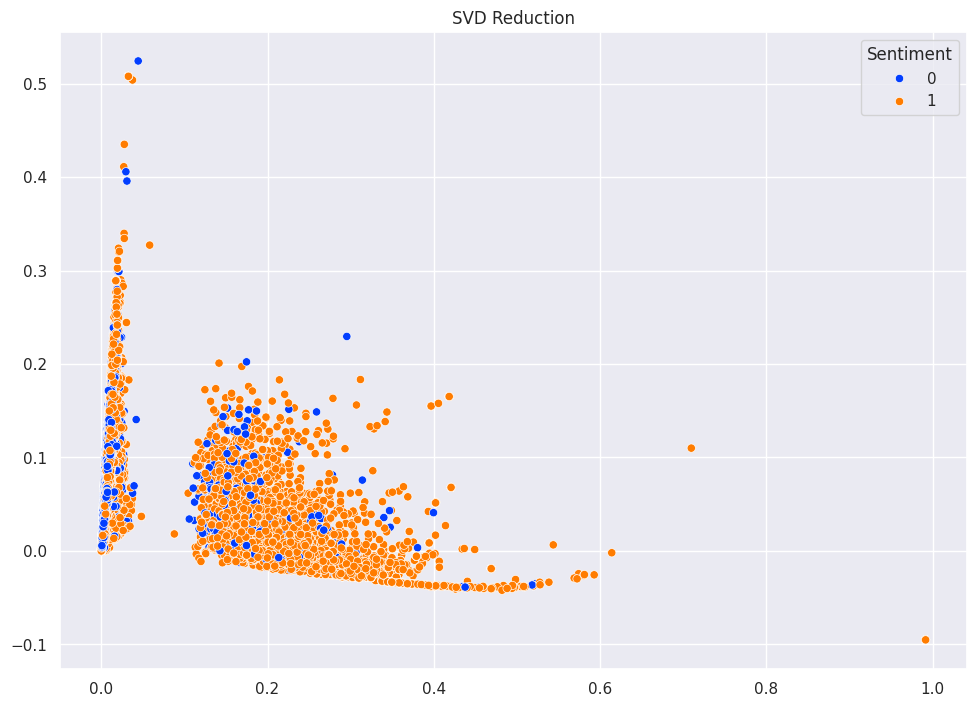

In [18]:
from sklearn.decomposition import TruncatedSVD

# Dimensionality Reduction using SVD
svd = TruncatedSVD(n_components=2, random_state=2025) # 2 components for 2D visualization
x_train_trunc = svd.fit_transform(x_train_tfidf)

plt.figure()
plt.title('SVD Reduction')
_=sns.scatterplot(x=x_train_trunc[:,0],
                y=x_train_trunc[:,1],
                hue=y_train,
                legend='full',
                palette=palette)

### **Model Training: Baseline and Logistic Regression Classifiers**

In this section, we compare three different classification approaches for tweet sentiment prediction. The aim is to evaluate how different feature representations (TF-IDF vs. Boolean presence) and model assumptions impact classification performance.

#### 1. **Majority Baseline Classifier**
The baseline model predicts the sentiment class that appears most frequently in the training set.  
This provides a **lower-bound performance benchmark**. A good classifier should significantly outperform this baseline.

#### 2. **Logistic Regression with TF-IDF and Character-Level Features**
This model uses a **hybrid feature representation**:
- **Word-level TF-IDF** features (unigrams, bigrams, trigrams)
- **Character-level n-grams** to capture stylistic cues, misspellings, slang, and emojis often found in tweets.

Additionally, we apply:
- **Feature selection using Mutual Information (`SelectKBest`)** to keep the most informative 30,000 features.
- **Class-balanced Logistic Regression** to counteract class imbalance.

This model is expected to capture both semantic and stylistic sentiment signals.

#### 3. **Logistic Regression with Boolean Bag-of-Words Features**
This model uses a **binary CountVectorizer** that records only the *presence or absence* of terms.  
This representation is simpler and may reduce noise, but it ignores term frequency and relative importance of words.

In [19]:
# === Two Pipelines: Baseline, Logistic Regression (TF-IDF) ===
import time
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import mutual_info_classif, SelectKBest
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# 1) Majority Baseline (most_frequent)
baseline = Pipeline([
    ("classifier", DummyClassifier(strategy="most_frequent", random_state=2025)),
])

# 2) Logistic Regression (TF-IDF)
vectorizer = FeatureUnion([
    ('word', TfidfVectorizer(ngram_range = (1, 3),max_features = 30000, stop_words='english', sublinear_tf = True)),
    # Character features help with misspellings, slang, and emojis.
    ('char', TfidfVectorizer(analyzer='char', ngram_range=(3,5), max_features=20000))
])

lr_tfidf = Pipeline([
    ('vectorizer', vectorizer),
    ('selector', SelectKBest(mutual_info_classif, k=30000)),
    ('classifier', LogisticRegression(max_iter=1000, n_jobs=-1, class_weight='balanced', C=1))
])

# Quick sanity fits + metrics
def quick_report(name, pipe, x_train, y_train, x_test, y_test):
    t0 = time.time()
    pipe.fit(x_train, y_train)
    dt = time.time() - t0
    ytr = pipe.predict(x_train)
    yte = pipe.predict(x_test)
    print(f"✓ {name} trained in {dt:.3f}s")
    print(f"  Train  Acc: {accuracy_score(y_train, ytr):.4f} | F1: {f1_score(y_train, ytr):.4f}")
    print(f"  Test   Acc: {accuracy_score(y_test, yte): .4f} | F1: {f1_score(y_test, yte): .4f}\n")
    return pipe

print("=== Evaluation ===")
baseline        = quick_report("Baseline",          baseline, x_train, y_train, x_test, y_test)
lr_tfidf        = quick_report("LR (TF-IDF)",       lr_tfidf, x_train, y_train, x_test, y_test)

trained_models = [
    ("Majority Baseline", baseline),
    ("TF-IDF+LR", lr_tfidf)
]


=== Evaluation ===
✓ Baseline trained in 0.003s
  Train  Acc: 0.5646 | F1: 0.7217
  Test   Acc:  0.5646 | F1:  0.7217

✓ LR (TF-IDF) trained in 641.943s
  Train  Acc: 0.8310 | F1: 0.8478
  Test   Acc:  0.7685 | F1:  0.7924



###  **Creating TF-IDF MLP**

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [21]:
class MLP_tf_idf(nn.Module):
    def __init__(self, input_dim=500, hidden_sizes=[256], dropout_prob=0.7):
        super().__init__()

        layers = []
        dim = input_dim

        for h in hidden_sizes:
            layers.append(nn.Linear(dim, h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_prob))
            dim = h

        # Final layer: 2 classes (negative/positive)
        layers.append(nn.Linear(dim, 2))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

mlp_classifier = MLP_tf_idf()
print(mlp_classifier)

# Count the total number of parameters
total_params = sum(p.numel() for p in mlp_classifier.parameters())
print(f"Total number of parameters: {total_params}")

# Count the number of trainable parameters
trainable_params = sum(p.numel() for p in mlp_classifier.parameters() if p.requires_grad)
print(f"Number of trainable parameters: {trainable_params}")

MLP_tf_idf(
  (model): Sequential(
    (0): Linear(in_features=500, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.7, inplace=False)
    (3): Linear(in_features=256, out_features=2, bias=True)
  )
)
Total number of parameters: 128770
Number of trainable parameters: 128770


In [22]:
from torch.utils.data import TensorDataset, DataLoader

X_train_tensor = torch.tensor(X_train_svd, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)

X_dev_tensor = torch.tensor(X_dev_svd, dtype=torch.float32)
y_dev_tensor = torch.tensor(y_dev.values, dtype=torch.long)

X_test_tensor = torch.tensor(X_test_svd, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

In [23]:
batch_size = 256

train_dataset = TensorDataset(X_train_tensor, y_train_tensor) # pairs each input vector with its label
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True) # divides it into mini-batches of 256 and reshuffles data every epoch (shuffle=True)

dev_dataset = TensorDataset(X_dev_tensor, y_dev_tensor)
dev_loader = DataLoader(dev_dataset, batch_size=batch_size, shuffle=False) #see whats best, shuffle=True or False

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False) #see whats best, shuffle=True or False

### **Hyperparameter Tuning**

## Hidden Layers

In [24]:
def train_hidden(hidden_sizes, epochs=250, lr=0.001, patience=5, min_delta=0.0):
    """
    patience : int
        Number of epochs to wait for improvement before stopping.
    min_delta : float
        Minimum decrease in dev loss to qualify as improvement.
    """
    model = MLP_tf_idf(hidden_sizes=hidden_sizes).to(device)
    optimizer = Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    history = {
        "train_loss": [],
        "dev_loss": [],
        "dev_acc": []
    }

    best_dev_loss = float('inf')
    epochs_no_improve = 0

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)

        # --- Validation ---
        model.eval()
        with torch.no_grad():
            dev_logits = model(X_dev_tensor.to(device))
            dev_loss = criterion(dev_logits, y_dev_tensor.to(device)).item()
            preds = torch.argmax(dev_logits, dim=1).cpu()
            dev_acc = (preds == y_dev_tensor).float().mean().item()

        history["train_loss"].append(avg_train_loss)
        history["dev_loss"].append(dev_loss)
        history["dev_acc"].append(dev_acc)

        print(f"[{hidden_sizes}] Epoch {epoch+1}/{epochs} | "
              f"Train loss={avg_train_loss:.4f} | Dev loss={dev_loss:.4f} | Dev Acc={dev_acc:.4f}")

        if dev_loss < best_dev_loss - min_delta:
            best_dev_loss = dev_loss
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    return model, history


In [25]:
architectures = [
    [512],
    [512, 256],
    [1024, 512, 256],
    [256],
    [1024, 1024]
]

results = {}

for arch in architectures:
    print(f"Training architecture: {arch}")
    model, history = train_hidden(arch, epochs=250, patience=5)
    results[str(arch)] = history


Training architecture: [512]
[[512]] Epoch 1/250 | Train loss=0.5847 | Dev loss=0.5479 | Dev Acc=0.7136
[[512]] Epoch 2/250 | Train loss=0.5387 | Dev loss=0.5464 | Dev Acc=0.7148
[[512]] Epoch 3/250 | Train loss=0.5339 | Dev loss=0.5454 | Dev Acc=0.7177
[[512]] Epoch 4/250 | Train loss=0.5315 | Dev loss=0.5451 | Dev Acc=0.7182
[[512]] Epoch 5/250 | Train loss=0.5288 | Dev loss=0.5446 | Dev Acc=0.7197
[[512]] Epoch 6/250 | Train loss=0.5260 | Dev loss=0.5444 | Dev Acc=0.7191
[[512]] Epoch 7/250 | Train loss=0.5222 | Dev loss=0.5440 | Dev Acc=0.7214
[[512]] Epoch 8/250 | Train loss=0.5187 | Dev loss=0.5440 | Dev Acc=0.7192
[[512]] Epoch 9/250 | Train loss=0.5165 | Dev loss=0.5435 | Dev Acc=0.7206
[[512]] Epoch 10/250 | Train loss=0.5127 | Dev loss=0.5436 | Dev Acc=0.7222
[[512]] Epoch 11/250 | Train loss=0.5088 | Dev loss=0.5431 | Dev Acc=0.7238
[[512]] Epoch 12/250 | Train loss=0.5064 | Dev loss=0.5446 | Dev Acc=0.7220
[[512]] Epoch 13/250 | Train loss=0.5013 | Dev loss=0.5429 | Dev Acc

In [26]:
summary_rows = []

for arch, hist in results.items():
    final_train = hist["train_loss"][-1]
    final_dev_loss = hist["dev_loss"][-1]
    final_dev_acc = hist["dev_acc"][-1]

    summary_rows.append({
        "Architecture": arch,
        "Train Loss": round(final_train, 4),
        "Dev Loss": round(final_dev_loss, 4),
        "Dev Accuracy": round(final_dev_acc, 4)
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df)


       Architecture  Train Loss  Dev Loss  Dev Accuracy
0             [512]      0.4872    0.5475        0.7220
1        [512, 256]      0.4833    0.5492        0.7209
2  [1024, 512, 256]      0.4720    0.5556        0.7180
3             [256]      0.5117    0.5449        0.7201
4      [1024, 1024]      0.4577    0.5516        0.7192


## Dropout

In [40]:
def tune_dropout(model_class,
                 hidden_sizes=[512],
                 dropout_range=None,
                 epochs=50,
                 lr=0.001,
                 patience=5,
                 device="cpu"):
    """
    Tune dropout by training the model with each value in dropout_range.
    Uses early stopping on dev loss.

    Returns:
        df: DataFrame with results per dropout
        best_model: trained PyTorch model with best dev accuracy
    """

    if dropout_range is None:
        dropout_range = np.linspace(0.1, 1.0, 10)
    dropout_range = [float(d) for d in dropout_range]

    results = []
    best_dev_acc = -1
    best_model = None

    for d in dropout_range:
        print(f"\nTraining with dropout={d:.2f}...")
        model = model_class(hidden_sizes=hidden_sizes, dropout_prob=d).to(device)
        optimizer = Adam(model.parameters(), lr=lr)
        criterion = nn.CrossEntropyLoss()

        best_epoch_dev_loss = np.inf
        patience_counter = 0

        for epoch in range(epochs):
            model.train()
            total_loss = 0

            for X_batch, y_batch in train_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)

                optimizer.zero_grad()
                logits = model(X_batch)
                loss = criterion(logits, y_batch)
                loss.backward()
                optimizer.step()

                total_loss += loss.item()

            avg_train_loss = total_loss / len(train_loader)

            # --- Validation ---
            model.eval()
            with torch.no_grad():
                dev_logits = model(X_dev_tensor.to(device))
                dev_loss = criterion(dev_logits, y_dev_tensor.to(device)).item()
                preds = torch.argmax(dev_logits, dim=1).cpu()
                dev_acc = (preds == y_dev_tensor).float().mean().item()

            print(f"Epoch {epoch+1}/{epochs} | "
                  f"Train Loss={avg_train_loss:.4f} | Dev Loss={dev_loss:.4f} | Dev Acc={dev_acc:.4f}")

            # Early stopping based on dev loss
            if dev_loss < best_epoch_dev_loss:
                best_epoch_dev_loss = dev_loss
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping at epoch {epoch+1}")
                    break

        # Save results
        results.append({
            "Dropout": d,
            "Train Loss": avg_train_loss,
            "Dev Loss": dev_loss,
            "Dev Accuracy": dev_acc
        })

        # Save best model by dev accuracy
        if dev_acc > best_dev_acc:
            best_dev_acc = dev_acc
            best_model = model_class(hidden_sizes=hidden_sizes, dropout_prob=d).to(device)
            # Copy the weights from current model
            best_model.load_state_dict(model.state_dict())

    df = pd.DataFrame(results).sort_values("Dropout").reset_index(drop=True)
    print("\n===== DROPOUT TUNING RESULTS =====\n")
    print(df)

    return df, best_model



In [41]:
df_dropout, best_model_dropout = tune_dropout(MLP_tf_idf, hidden_sizes=[512], epochs=250, device=device)



Training with dropout=0.10...
Epoch 1/250 | Train Loss=0.5711 | Dev Loss=0.5497 | Dev Acc=0.7109
Epoch 2/250 | Train Loss=0.5355 | Dev Loss=0.5462 | Dev Acc=0.7178
Epoch 3/250 | Train Loss=0.5302 | Dev Loss=0.5466 | Dev Acc=0.7148
Epoch 4/250 | Train Loss=0.5245 | Dev Loss=0.5448 | Dev Acc=0.7199
Epoch 5/250 | Train Loss=0.5170 | Dev Loss=0.5442 | Dev Acc=0.7201
Epoch 6/250 | Train Loss=0.5074 | Dev Loss=0.5458 | Dev Acc=0.7185
Epoch 7/250 | Train Loss=0.4980 | Dev Loss=0.5459 | Dev Acc=0.7200
Epoch 8/250 | Train Loss=0.4859 | Dev Loss=0.5461 | Dev Acc=0.7207
Epoch 9/250 | Train Loss=0.4752 | Dev Loss=0.5486 | Dev Acc=0.7179
Epoch 10/250 | Train Loss=0.4632 | Dev Loss=0.5563 | Dev Acc=0.7165
Early stopping at epoch 10

Training with dropout=0.20...
Epoch 1/250 | Train Loss=0.5717 | Dev Loss=0.5492 | Dev Acc=0.7145
Epoch 2/250 | Train Loss=0.5357 | Dev Loss=0.5469 | Dev Acc=0.7166
Epoch 3/250 | Train Loss=0.5310 | Dev Loss=0.5448 | Dev Acc=0.7148
Epoch 4/250 | Train Loss=0.5259 | Dev L

In [42]:
# Find the row with the maximum Dev Accuracy
best_row = df_dropout.loc[df_dropout['Dev Accuracy'].idxmax()]

print(f"Best dropout: {best_row['Dropout']:.2f}")
print(f"Dev Accuracy: {best_row['Dev Accuracy']:.4f}")


Best dropout: 0.70
Dev Accuracy: 0.7225


## Epoch

In [30]:
def epoch_tuning(model, train_loader, X_dev_tensor, y_dev_tensor, epochs=200, lr=0.001, device="cpu"):

    optimizer = Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    history = {
        "train_loss": [],
        "dev_loss": [],
        "dev_acc": []
    }

    best_epoch = -1
    best_dev_acc = 0.0

    for epoch in range(epochs):
        # -------- TRAIN --------
        model.train()
        total_loss = 0.0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)

        # -------- DEV EVALUATION --------
        model.eval()
        with torch.no_grad():
            dev_logits = model(X_dev_tensor.to(device))
            dev_loss = criterion(dev_logits, y_dev_tensor.to(device)).item()
            preds = torch.argmax(dev_logits, dim=1).cpu()
            dev_acc = (preds == y_dev_tensor.cpu()).float().mean().item()

        # Save history
        history["train_loss"].append(avg_train_loss)
        history["dev_loss"].append(dev_loss)
        history["dev_acc"].append(dev_acc)

        # Track best epoch
        if dev_acc > best_dev_acc:
            best_dev_acc = dev_acc
            best_epoch = epoch + 1

    print("\n=====================================")
    print(f"Best dev accuracy: {best_dev_acc:.4f} at epoch {best_epoch}")
    print("=====================================\n")

    return history, best_epoch


In [43]:
model = MLP_tf_idf(hidden_sizes=[512], dropout_prob=0.7).to(device)

history, best_epoch = epoch_tuning(
    model=model,
    train_loader=train_loader,
    X_dev_tensor=X_dev_tensor,
    y_dev_tensor=y_dev_tensor,
    epochs=200,
    lr=0.001,
    device=device
)


Best dev accuracy: 0.7227 at epoch 26



## **Creating the final model**

In [44]:
from sklearn.metrics import f1_score

def train_final_model(hidden_sizes, dropout_prob, epochs, lr=0.001):
    model = MLP_tf_idf(hidden_sizes=hidden_sizes, dropout_prob=0.7).to(device)
    optimizer = Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    history = {
        "train_loss": [],
        "dev_loss": [],
        "train_accuracy": [],
        "val_accuracy": [],
        "train_f1_score": [],
        "val_f1_score": []
    }

    for epoch in range(epochs):
        model.train()
        running_loss = 0
        all_train_preds = []
        all_train_labels = []

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            preds_train = torch.argmax(logits, dim=1)
            all_train_preds.append(preds_train.cpu())
            all_train_labels.append(y_batch.cpu())

        # --- Training metrics ---
        train_preds_tensor = torch.cat(all_train_preds)
        train_labels_tensor = torch.cat(all_train_labels)
        train_acc = (train_preds_tensor == train_labels_tensor).float().mean().item()
        train_f1 = f1_score(train_labels_tensor, train_preds_tensor, average='macro')

        avg_train_loss = running_loss / len(train_loader)

        # --- Validation metrics ---
        model.eval()
        with torch.no_grad():
            dev_logits = model(X_dev_tensor.to(device))
            dev_loss = criterion(dev_logits, y_dev_tensor.to(device)).item()
            dev_preds = torch.argmax(dev_logits, dim=1).cpu()
            val_acc = (dev_preds == y_dev_tensor).float().mean().item()
            val_f1 = f1_score(y_dev, dev_preds, average='macro')

        # --- Append to history ---
        history["train_loss"].append(avg_train_loss)
        history["dev_loss"].append(dev_loss)
        history["train_accuracy"].append(train_acc)
        history["val_accuracy"].append(val_acc)
        history["train_f1_score"].append(train_f1)
        history["val_f1_score"].append(val_f1)

        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss={avg_train_loss:.4f} | Dev Loss={dev_loss:.4f} | "
              f"Train Acc={train_acc:.4f} | Val Acc={val_acc:.4f} | "
              f"Train F1={train_f1:.4f} | Val F1={val_f1:.4f}")

    return model, history



In [45]:
best_model, history = train_final_model(
    hidden_sizes=[512],
    dropout_prob=0.7,
    epochs=26,
    lr=0.001
)

Epoch 1/26 | Train Loss=0.5853 | Dev Loss=0.5488 | Train Acc=0.6775 | Val Acc=0.7150 | Train F1=0.6456 | Val F1=0.7020
Epoch 2/26 | Train Loss=0.5388 | Dev Loss=0.5460 | Train Acc=0.7211 | Val Acc=0.7173 | Train F1=0.7096 | Val F1=0.7081
Epoch 3/26 | Train Loss=0.5348 | Dev Loss=0.5465 | Train Acc=0.7232 | Val Acc=0.7161 | Train F1=0.7118 | Val F1=0.7090
Epoch 4/26 | Train Loss=0.5314 | Dev Loss=0.5447 | Train Acc=0.7275 | Val Acc=0.7189 | Train F1=0.7166 | Val F1=0.7093
Epoch 5/26 | Train Loss=0.5287 | Dev Loss=0.5446 | Train Acc=0.7284 | Val Acc=0.7176 | Train F1=0.7176 | Val F1=0.7053
Epoch 6/26 | Train Loss=0.5262 | Dev Loss=0.5441 | Train Acc=0.7306 | Val Acc=0.7175 | Train F1=0.7198 | Val F1=0.7057
Epoch 7/26 | Train Loss=0.5223 | Dev Loss=0.5441 | Train Acc=0.7347 | Val Acc=0.7200 | Train F1=0.7243 | Val F1=0.7096
Epoch 8/26 | Train Loss=0.5197 | Dev Loss=0.5442 | Train Acc=0.7350 | Val Acc=0.7202 | Train F1=0.7244 | Val F1=0.7094
Epoch 9/26 | Train Loss=0.5153 | Dev Loss=0.5441

In [46]:
from sklearn.metrics import classification_report, accuracy_score

best_model.eval()
best_model.to("cpu")  # move to CPU for sklearn

# Dev predictions
with torch.no_grad():
    dev_logits = best_model(X_dev_tensor)
    dev_preds = torch.argmax(dev_logits, dim=1)

# Test predictions
with torch.no_grad():
    test_logits = best_model(X_test_tensor)
    test_preds = torch.argmax(test_logits, dim=1)

print(f"Dev Accuracy:  {accuracy_score(y_dev, dev_preds)*100:.2f}%")
print(f"Test Accuracy: {accuracy_score(y_test, test_preds)*100:.2f}%")

print("\nDev performance:")
print(classification_report(y_dev, dev_preds, target_names=['Negative', 'Positive'], digits=4))

print("\nTest performance:")
print(classification_report(y_test, test_preds, target_names=['Negative', 'Positive'], digits=4))


Dev Accuracy:  72.22%
Test Accuracy: 72.13%

Dev performance:
              precision    recall  f1-score   support

    Negative     0.7021    0.6286    0.6633      6530
    Positive     0.7350    0.7943    0.7635      8468

    accuracy                         0.7222     14998
   macro avg     0.7185    0.7115    0.7134     14998
weighted avg     0.7207    0.7222    0.7199     14998


Test performance:
              precision    recall  f1-score   support

    Negative     0.7040    0.6210    0.6599      6530
    Positive     0.7321    0.7987    0.7639      8469

    accuracy                         0.7213     14999
   macro avg     0.7181    0.7098    0.7119     14999
weighted avg     0.7199    0.7213    0.7186     14999



In [47]:
best_model.eval()
best_model.to("cpu")

# --- Validation accuracy ---
y_pred_val = torch.argmax(best_model(X_dev_tensor), dim=1)
val_acc = accuracy_score(y_dev, y_pred_val)
print(f'Validation Accuracy: {val_acc*100:.2f}%')

# --- Test accuracy ---
y_pred_test = torch.argmax(best_model(X_test_tensor), dim=1)
test_acc = accuracy_score(y_test, y_pred_test)
print(f'Test Accuracy: {test_acc*100:.2f}%')


Validation Accuracy: 72.22%
Test Accuracy: 72.13%


## **Curves**

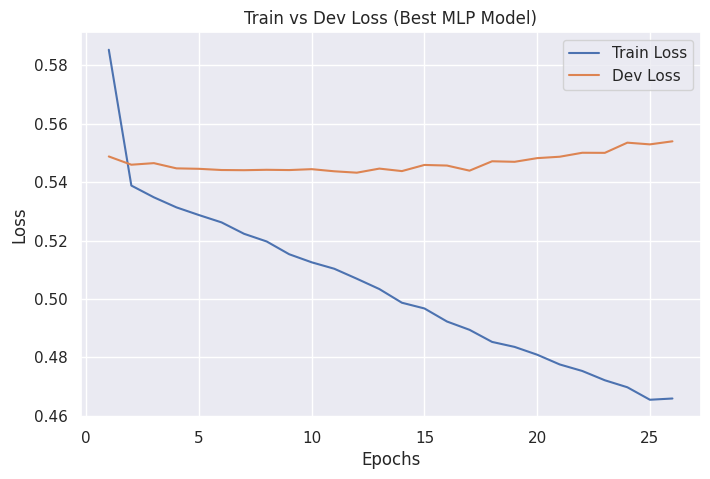

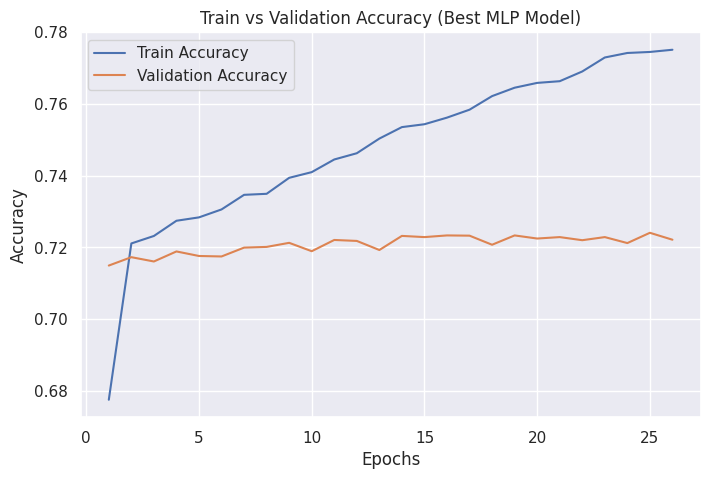

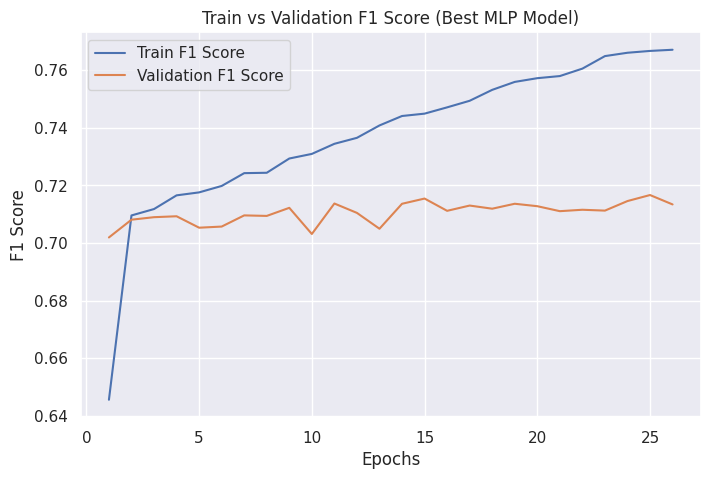

In [48]:
import matplotlib.pyplot as plt

def plot_training_history(history, title_suffix=""):

    epochs = range(1, len(history['train_loss']) + 1)

    # --- Loss ---
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history['train_loss'], label='Train Loss')
    plt.plot(epochs, history['dev_loss'], label='Dev Loss')
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title(f"Train vs Dev Loss {title_suffix}")
    plt.legend()
    plt.grid(True)
    plt.show()

    # --- Accuracy ---
    if 'train_accuracy' in history and 'val_accuracy' in history:
        plt.figure(figsize=(8, 5))
        plt.plot(epochs, history['train_accuracy'], label='Train Accuracy')
        plt.plot(epochs, history['val_accuracy'], label='Validation Accuracy')
        plt.xlabel("Epochs")
        plt.ylabel("Accuracy")
        plt.title(f"Train vs Validation Accuracy {title_suffix}")
        plt.legend()
        plt.grid(True)
        plt.show()

    # --- F1 Score ---
    if 'train_f1_score' in history and 'val_f1_score' in history:
        plt.figure(figsize=(8, 5))
        plt.plot(epochs, history['train_f1_score'], label='Train F1 Score')
        plt.plot(epochs, history['val_f1_score'], label='Validation F1 Score')
        plt.xlabel("Epochs")
        plt.ylabel("F1 Score")
        plt.title(f"Train vs Validation F1 Score {title_suffix}")
        plt.legend()
        plt.grid(True)
        plt.show()


plot_training_history(history, title_suffix="(Best MLP Model)")





## **Comparison with other models**

In [49]:
from sklearn.metrics import precision_recall_fscore_support, average_precision_score

def per_class_prf(y_true, y_pred, label_order):
    P, R, F1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=label_order, average=None, zero_division=0
    )
    return {lbl: (float(p), float(r), float(f1)) for lbl, p, r, f1 in zip(label_order, P, R, F1)}

def per_class_prauc(y_true, proba, label_order):
    y_true = np.asarray(y_true)
    ap = {}
    for j, lbl in enumerate(label_order):
        y_bin = (y_true == lbl).astype(int)
        y_score = proba[:, j]
        ap[lbl] = float(average_precision_score(y_bin, y_score))
    return ap

def make_results_row(name, y_true, y_pred, y_proba, label_order):
    prf = per_class_prf(y_true, y_pred, label_order)
    ap  = per_class_prauc(y_true, y_proba, label_order)

    row = {"Model": name}
    per_class_vals = []
    for lbl in label_order:
        P, R, F1 = prf[lbl]
        A = ap[lbl]
        row[f"P({lbl})"]      = P
        row[f"R({lbl})"]      = R
        row[f"F1({lbl})"]     = F1
        row[f"PR-AUC({lbl})"] = A
        per_class_vals.append((P, R, F1, A))

    macro = np.mean(per_class_vals, axis=0)
    row["Macro-P"]      = float(macro[0])
    row["Macro-R"]      = float(macro[1])
    row["Macro-F1"]     = float(macro[2])
    row["Macro-PR-AUC"] = float(macro[3])
    return row


In [50]:
# 1) Majority baseline
baseline = baseline      # already fitted earlier, or refit

# 2) Best LR from exercise 2
best_lr = lr_tfidf       # treat this as "TF-IDF+LR"

# 3) MLP wrapper so we can call predict / predict_proba
from sklearn.base import BaseEstimator, ClassifierMixin

class MLPWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, model):
        self.model = model.eval().to("cpu")

    def predict(self, X):
        X_tensor = torch.tensor(X, dtype=torch.float32)
        with torch.no_grad():
            logits = self.model(X_tensor)
            preds = torch.argmax(logits, dim=1).numpy()
        return preds

    def predict_proba(self, X):
        X_tensor = torch.tensor(X, dtype=torch.float32)
        with torch.no_grad():
            logits = self.model(X_tensor)
            probs = torch.softmax(logits, dim=1).numpy()
        return probs

mlp_clf = MLPWrapper(best_model)


In [51]:
label_order = [0, 1]  # Negative, Positive

train_rows = []
dev_rows = []
test_rows = []

# Baseline
baseline.fit(x_train, y_train)  # baseline works on raw text, ok
y_train_pred_b = baseline.predict(x_train)
y_dev_pred_b   = baseline.predict(x_dev)
y_test_pred_b  = baseline.predict(x_test)

y_train_proba_b = baseline.predict_proba(x_train)
y_dev_proba_b   = baseline.predict_proba(x_dev)
y_test_proba_b  = baseline.predict_proba(x_test)

train_rows.append(make_results_row("Baseline", y_train, y_train_pred_b, y_train_proba_b, label_order))
dev_rows.append(make_results_row("Baseline",   y_dev,   y_dev_pred_b,   y_dev_proba_b,   label_order))
test_rows.append(make_results_row("Baseline",  y_test,  y_test_pred_b,  y_test_proba_b,  label_order))

# TF-IDF + LR (best from assg 2)
best_lr.fit(x_train, y_train)
y_train_pred_lr = best_lr.predict(x_train)
y_dev_pred_lr   = best_lr.predict(x_dev)
y_test_pred_lr  = best_lr.predict(x_test)

y_train_proba_lr = best_lr.predict_proba(x_train)
y_dev_proba_lr   = best_lr.predict_proba(x_dev)
y_test_proba_lr  = best_lr.predict_proba(x_test)

train_rows.append(make_results_row("TF-IDF+LR", y_train, y_train_pred_lr, y_train_proba_lr, label_order))
dev_rows.append(make_results_row("TF-IDF+LR",   y_dev,   y_dev_pred_lr,   y_dev_proba_lr,   label_order))
test_rows.append(make_results_row("TF-IDF+LR",  y_test,  y_test_pred_lr,  y_test_proba_lr,  label_order))

# MLP (on SVD features)
y_train_pred_m = mlp_clf.predict(X_train_svd)
y_dev_pred_m   = mlp_clf.predict(X_dev_svd)
y_test_pred_m  = mlp_clf.predict(X_test_svd)

y_train_proba_m = mlp_clf.predict_proba(X_train_svd)
y_dev_proba_m   = mlp_clf.predict_proba(X_dev_svd)
y_test_proba_m  = mlp_clf.predict_proba(X_test_svd)

train_rows.append(make_results_row("MLP", y_train, y_train_pred_m, y_train_proba_m, label_order))
dev_rows.append(make_results_row("MLP",   y_dev,   y_dev_pred_m,   y_dev_proba_m,   label_order))
test_rows.append(make_results_row("MLP",  y_test,  y_test_pred_m,  y_test_proba_m,  label_order))

cols = ["Model"]
for lbl in label_order:
    cols += [f"P({lbl})", f"R({lbl})", f"F1({lbl})", f"PR-AUC({lbl})"]
cols += ["Macro-P", "Macro-R", "Macro-F1", "Macro-PR-AUC"]

train_df = pd.DataFrame(train_rows)[cols]
dev_df   = pd.DataFrame(dev_rows)[cols]
test_df  = pd.DataFrame(test_rows)[cols]

print("=== TRAIN RESULTS ===")
display(train_df)
print("\n=== DEV RESULTS ===")
display(dev_df)
print("\n=== TEST RESULTS ===")
display(test_df)


=== TRAIN RESULTS ===


,Model,P(0),R(0),F1(0),PR-AUC(0),P(1),R(1),F1(1),PR-AUC(1),Macro-P,Macro-R,Macro-F1,Macro-PR-AUC
0,Baseline,0.000000,0.000000,0.000000,0.435364,0.564636,1.000000,0.721747,0.564636,0.282318,0.500000,0.360874,0.500000
1,TF-IDF+LR,0.793206,0.827645,0.810060,0.878431,0.862502,0.833629,0.847820,0.930190,0.827854,0.830637,0.828940,0.904310
2,MLP,0.818141,0.725486,0.769033,0.868709,0.805334,0.875658,0.839025,0.911225,0.811738,0.800572,0.804029,0.889967



=== DEV RESULTS ===


,Model,P(0),R(0),F1(0),PR-AUC(0),P(1),R(1),F1(1),PR-AUC(1),Macro-P,Macro-R,Macro-F1,Macro-PR-AUC
0,Baseline,0.000000,0.000000,0.000000,0.435391,0.564609,1.000000,0.721725,0.564609,0.282304,0.500000,0.360863,0.500000
1,TF-IDF+LR,0.722174,0.757121,0.739234,0.805588,0.805447,0.775390,0.790132,0.876435,0.763810,0.766255,0.764683,0.841011
2,MLP,0.702069,0.628637,0.663327,0.746026,0.735002,0.794284,0.763494,0.827080,0.718536,0.711461,0.713411,0.786553



=== TEST RESULTS ===


,Model,P(0),R(0),F1(0),PR-AUC(0),P(1),R(1),F1(1),PR-AUC(1),Macro-P,Macro-R,Macro-F1,Macro-PR-AUC
0,Baseline,0.000000,0.000000,0.000000,0.435362,0.564638,1.000000,0.721749,0.564638,0.282319,0.500000,0.360874,0.500000
1,TF-IDF+LR,0.726814,0.750077,0.738262,0.810192,0.802421,0.782619,0.792396,0.875979,0.764618,0.766348,0.765329,0.843085
2,MLP,0.703993,0.620980,0.659886,0.753566,0.732114,0.798678,0.763948,0.825389,0.718053,0.709829,0.711917,0.789477
